### MINERvA ME one-step reweight for NEUT: old Valencia to new Valencia exclusive 

In [1]:
import sys
sys.path.append('/exp/minerva/app/users/zihaolin/REWEIGHTworkdir/')
from BDTReweight.nuisance_flat_tree import NuisanceFlatTree
from BDTReweight.analysis import transform_momentum_to_reaction_frame, draw_source_target_distributions_and_ratio, create_dataframe_from_nuisance
from BDTReweight.reweighter import Reweighter
from BDTReweight.utilities import particle_mass_lookup
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# dict object to store data frames
oldInclusive = {}
newExclusive = {}
size = 1000000
# size = 10000

# change this
exclusive_size_pp = 100000 
exclusive_size_pn = 50000


Prepare new exclusive pp and pn:

In [3]:
# prepare new exclusive pp:
category = 'pp'


# new Valencia inclusive, exclusive:
variables = {'muon_E':'leading_muon_E', 'muon_Px':'leading_muon_px', 'muon_Py':'leading_muon_py', 'muon_Pz':'leading_muon_pz', 'muon_P':'leading_muon_P', 
    'neutrino_E':'init_neutrino_E', 'neutrino_Px':'init_neutrino_px', 'neutrino_Py':'init_neutrino_py',
    'neutrino_Pz':'init_neutrino_pz', 'neutrino_P':'init_neutrino_P',
    'nucleon1_out_E':'leading_proton_E', 'nucleon1_out_Px':'leading_proton_px', 'nucleon1_out_Py':'leading_proton_py', 
    'nucleon1_out_Pz':'leading_proton_pz','nucleon1_out_P':'leading_proton_P',
    'nucleon2_out_E':'subleading_proton_E', 'nucleon2_out_Px':'subleading_proton_px', 'nucleon2_out_Py':'subleading_proton_py', 
    'nucleon2_out_Pz':'subleading_proton_pz','nucleon2_out_P':'subleading_proton_P', 
    'Q_E':'qtransfer_E', 'Q_Px':'qtransfer_px', 'Q_Py':'qtransfer_py', 'Q_Pz':'qtransfer_pz', 'Q_P':'qtransfer_P', 'weight_pp':'weight'}

data_folder = '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/PreFsi'



newExclusive[category] = uproot.open(f'{data_folder}/KinematicVariables_Enu=_Minerva__Exclusive.root')['T'].arrays(library='pd',entry_start=0, entry_stop=exclusive_size_pp)[variables.keys()]



# drop Enu > 20 GeV for now
newExclusive[category] = newExclusive[category].loc[newExclusive[category]['neutrino_E'] <= 20000.0]

# relabel nucleon 1 and 2 to ensure nucleon1_out_E >= nucleon2_out_E 
mask = newExclusive[category]['nucleon1_out_E'] < newExclusive[category]['nucleon2_out_E']
newExclusive[category].loc[mask, ['nucleon1_out_E', 'nucleon2_out_E']] = newExclusive[category].loc[mask, ['nucleon2_out_E', 'nucleon1_out_E']].to_numpy()
newExclusive[category].loc[mask, ['nucleon1_out_P', 'nucleon2_out_P']] = newExclusive[category].loc[mask, ['nucleon2_out_P', 'nucleon1_out_P']].to_numpy()
newExclusive[category].loc[mask, ['nucleon1_out_Px', 'nucleon2_out_Px']] = newExclusive[category].loc[mask, ['nucleon2_out_Px', 'nucleon1_out_Px']].to_numpy()
newExclusive[category].loc[mask, ['nucleon1_out_Py', 'nucleon2_out_Py']] = newExclusive[category].loc[mask, ['nucleon2_out_Py', 'nucleon1_out_Py']].to_numpy()
newExclusive[category].loc[mask, ['nucleon1_out_Pz', 'nucleon2_out_Pz']] = newExclusive[category].loc[mask, ['nucleon2_out_Pz', 'nucleon1_out_Pz']].to_numpy()




newExclusive[category] = newExclusive[category].rename(columns = variables)

newExclusive[category] = newExclusive[category].loc[newExclusive[category]['weight']>=0]

newExclusive[category] = transform_momentum_to_reaction_frame(newExclusive[category], selector_lepton='leading_muon',particle_names=['leading_proton','subleading_proton','qtransfer'])
# for df in [source_train, source_test, target_train, target_test]:
for df in [newExclusive[category]]:
    df['q0'] = df['qtransfer_E']
    df['q3'] = df['qtransfer_P']
    df['Q2'] = df['q3']**2 - df['q0']**2



In [4]:
# prepare new exclusive pn:
category = 'pn'
# new Valencia inclusive, exclusive:
variables = {
    'muon_E':'leading_muon_E', 'muon_Px':'leading_muon_px', 'muon_Py':'leading_muon_py', 'muon_Pz':'leading_muon_pz', 'muon_P':'leading_muon_P', 
    'neutrino_E':'init_neutrino_E', 'neutrino_Px':'init_neutrino_px', 'neutrino_Py':'init_neutrino_py', 'neutrino_Pz':'init_neutrino_pz', 'neutrino_P':'init_neutrino_P',
    'nucleon1_out_E':'leading_proton_E', 'nucleon1_out_Px':'leading_proton_px', 'nucleon1_out_Py':'leading_proton_py', 'nucleon1_out_Pz':'leading_proton_pz','nucleon1_out_P':'leading_proton_P',
    'nucleon2_out_E':'leading_neutron_E', 'nucleon2_out_Px':'leading_neutron_px', 'nucleon2_out_Py':'leading_neutron_py', 'nucleon2_out_Pz':'leading_neutron_pz','nucleon2_out_P':'leading_neutron_P', 
    'Q_E':'qtransfer_E', 'Q_Px':'qtransfer_px', 'Q_Py':'qtransfer_py', 'Q_Pz':'qtransfer_pz', 'Q_P':'qtransfer_P'}

data_folder = '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/PreFsi'


newExclusive[category] = uproot.open(f'{data_folder}/KinematicVariables_Enu=_Minerva__Exclusive.root')['T'].arrays(library='pd',entry_start=exclusive_size_pp, entry_stop=exclusive_size_pp+exclusive_size_pn)[variables.keys()]
newExclusive[category] = newExclusive[category].rename(columns = variables)

# weight = weight_pn + weight_np
df_weight = uproot.open(f'{data_folder}/KinematicVariables_Enu=_Minerva__Exclusive.root')['T'].arrays(library='pd',entry_start=exclusive_size_pp, entry_stop=exclusive_size_pp+exclusive_size_pn)[['weight_pn','weight_np']]
newExclusive[category]['weight'] = df_weight['weight_pn'] + df_weight['weight_np']


newExclusive[category] = newExclusive[category].loc[newExclusive[category]['weight']>=0]

# drop Enu > 10 GeV for now
newExclusive[category] = newExclusive[category].loc[newExclusive[category]['init_neutrino_E'] <= 20000.0]


newExclusive[category] = transform_momentum_to_reaction_frame(newExclusive[category], selector_lepton='leading_muon',particle_names=['leading_proton','leading_neutron','qtransfer'])
# for df in [source_train, source_test, target_train, target_test]:
for df in [newExclusive[category]]:
    df['q0'] = df['qtransfer_E']
    df['q3'] = df['qtransfer_P']
    df['Q2'] = df['q3']**2 - df['q0']**2




Handle and prepare old inclusive 3p3h:

In [5]:
# prepare 3p3h pp and pn
tree_neut = NuisanceFlatTree(
    '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors.root',
    # '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/NEUT_output_files/NEUT:OldValencia_2p2h_minervaFlux_10k.root.GenericVectors.root',
    entry_start = 0, entry_stop = size)
mask_3p3h = (tree_neut._flattree_vars['Enu_true'] <= 20.0) & (tree_neut._flattree_vars['Mode'] == 2) & (tree_neut._flattree_vars['nvertp'] == 8)
tree_neut.update_tree_with_mask(mask_3p3h)

vertp_pdg = tree_neut._flattree_vars['pdg_vert'][:,5:]
vertp_E = tree_neut._flattree_vars['E_vert'][:,5:]
vertp_mass = ak.where(vertp_pdg == 2212, particle_mass_lookup('proton'),
    ak.where(vertp_pdg == 2112, particle_mass_lookup('neutron'), -999.0)
)
vertp_KE = vertp_E - vertp_mass
order = ak.argsort(vertp_KE, axis=1, ascending=False)
primary_pdg = vertp_pdg[order][:,0]
spectator_pdg = vertp_pdg[order][:,1]

mask3p3h = {}
mask3p3h['pp'] = (primary_pdg == 2212) & (spectator_pdg == 2212)
mask3p3h['pn'] = ~ ((primary_pdg == 2212) & (spectator_pdg == 2112))
# mask3p3h['np'] = primary_pdg == 2112

oldInclusive3p3h = {}
# for key in ['pp', 'pn', 'np']:
for key in ['pp', 'pn']:
    oldInclusive3p3h[key] = create_dataframe_from_nuisance(tree_neut, variable_exprs=['Enu_true'], mask = mask3p3h[key])
    oldInclusive3p3h[key] = oldInclusive3p3h[key].rename(columns = {'Enu_true':'init_neutrino_E'})
    oldInclusive3p3h[key]['init_neutrino_E'] = oldInclusive3p3h[key]['init_neutrino_E'] * 1e3

Prepare old inclusive pp and pn at vertex:

In [6]:
# Feb23: This file has FSI: use vertex info. old Valencia inclusive as implemented in NEUT: (total entries: 10000000)
tree_neut = NuisanceFlatTree(
    '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors.root',
    # '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/NEUT_output_files/NEUT:OldValencia_2p2h_minervaFlux_10k.root.GenericVectors.root',
    entry_start = 0, entry_stop = size)

# drop Enu > 10 GeV events for now
mask_2p2h = (tree_neut._flattree_vars['Enu_true'] <= 20.0) & (tree_neut._flattree_vars['Mode'] == 2) & (tree_neut._flattree_vars['nvertp'] == 6)
entries_2p2h = np.arange(0, len(mask_2p2h), 1)[mask_2p2h]
tree_neut.update_tree_with_mask(mask_2p2h)

# create df
oldInclusive['pp'] = pd.DataFrame()
oldInclusive['pn'] = pd.DataFrame()
# oldInclusive['np'] = pd.DataFrame()


vertp_pdg = tree_neut._flattree_vars['pdg_vert'][:,4:]
vertp_E = tree_neut._flattree_vars['E_vert'][:,4:]
vertp_px = tree_neut._flattree_vars['px_vert'][:,4:]
vertp_py = tree_neut._flattree_vars['py_vert'][:,4:]
vertp_pz = tree_neut._flattree_vars['pz_vert'][:,4:]


vertp_mass = ak.where(vertp_pdg == 2212, particle_mass_lookup('proton'),
    ak.where(vertp_pdg == 2112, particle_mass_lookup('neutron'), -999.0)
)
vertp_KE = vertp_E - vertp_mass
order = ak.argsort(vertp_KE, axis=1, ascending=False)
primary_pdg = vertp_pdg[order][:,0]
spectator_pdg = vertp_pdg[order][:,1]

maskvertp = {}
maskvertp['pp'] = (primary_pdg == 2212) & (spectator_pdg == 2212)
maskvertp['pn'] = ~ ((primary_pdg == 2212) & (spectator_pdg == 2212))
# maskvertp['np'] = primary_pdg == 2112

# keep track of entries:
entrie_pp = entries_2p2h[maskvertp['pp']]
entrie_pn = entries_2p2h[maskvertp['pn']]
print(len(entrie_pp), len(entrie_pn), len(entries_2p2h))

# get muon kinematics, momentum transfer, and Enu first:
# for category in ['pp', 'pn', 'np']:
for category in ['pp', 'pn']:
    oldInclusive[category]['leading_muon_px'] = tree_neut._flattree_vars['px_vert'][:,3][maskvertp[category]] * 1e3
    oldInclusive[category]['leading_muon_py'] = tree_neut._flattree_vars['py_vert'][:,3][maskvertp[category]] * 1e3
    oldInclusive[category]['leading_muon_pz'] = tree_neut._flattree_vars['pz_vert'][:,3][maskvertp[category]] * 1e3
    oldInclusive[category]['init_neutrino_E'] = tree_neut._flattree_vars['Enu_true'][maskvertp[category]] * 1e3
    oldInclusive[category]['q0'] = tree_neut._flattree_vars['q0'][maskvertp[category]] * 1e3
    oldInclusive[category]['q3'] = tree_neut._flattree_vars['q3'][maskvertp[category]] * 1e3
    oldInclusive[category]['Q2'] = tree_neut._flattree_vars['Q2'][maskvertp[category]] * 1e6



# pp channel proton kinematics:
category = 'pp'
leading_i = ak.argmax(vertp_KE, axis=1, keepdims=True)
subleading_i = ak.argmin(vertp_KE, axis=1, keepdims=True)
oldInclusive[category]['leading_proton_px'] = vertp_px[leading_i][maskvertp[category]] * 1e3
oldInclusive[category]['leading_proton_py'] = vertp_py[leading_i][maskvertp[category]] * 1e3
oldInclusive[category]['leading_proton_pz'] = vertp_pz[leading_i][maskvertp[category]] * 1e3
oldInclusive[category]['subleading_proton_px'] = vertp_px[subleading_i][maskvertp[category]] * 1e3
oldInclusive[category]['subleading_proton_py'] = vertp_py[subleading_i][maskvertp[category]] * 1e3
oldInclusive[category]['subleading_proton_pz'] = vertp_pz[subleading_i][maskvertp[category]] * 1e3
oldInclusive[category] = transform_momentum_to_reaction_frame(oldInclusive[category],
    selector_lepton='leading_muon', particle_names=['leading_proton', 'subleading_proton'])

# pn channel
category = 'pn'
oldInclusive[category]['leading_proton_px'] = ak.firsts(vertp_px[vertp_pdg == 2212])[maskvertp['pn']] * 1e3
oldInclusive[category]['leading_proton_py'] = ak.firsts(vertp_py[vertp_pdg == 2212])[maskvertp['pn']] * 1e3
oldInclusive[category]['leading_proton_pz'] = ak.firsts(vertp_pz[vertp_pdg == 2212])[maskvertp['pn']] * 1e3
oldInclusive[category]['leading_neutron_px'] = ak.firsts(vertp_px[vertp_pdg == 2112])[maskvertp['pn']] * 1e3
oldInclusive[category]['leading_neutron_py'] = ak.firsts(vertp_py[vertp_pdg == 2112])[maskvertp['pn']] * 1e3
oldInclusive[category]['leading_neutron_pz'] = ak.firsts(vertp_pz[vertp_pdg == 2112])[maskvertp['pn']] * 1e3
oldInclusive[category] = transform_momentum_to_reaction_frame(oldInclusive[category],
    selector_lepton='leading_muon', particle_names=['leading_proton', 'leading_neutron'])

# keep track of entries:
oldInclusive['pp']['entry'] = entrie_pp
oldInclusive['pn']['entry'] = entrie_pn



11253 5579 16832


Scale up old inclusive 2p2h strength by 3p3h:

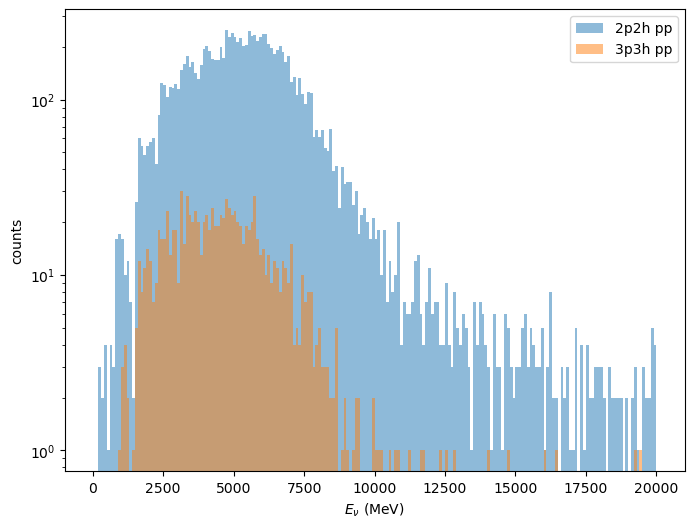

/tmp/ipykernel_3231846/3764424737.py:14: RuntimeWarning: divide by zero encountered in divide
  ratio = (n2p2h + n3p3h) / n2p2h
/tmp/ipykernel_3231846/3764424737.py:14: RuntimeWarning: invalid value encountered in divide
  ratio = (n2p2h + n3p3h) / n2p2h


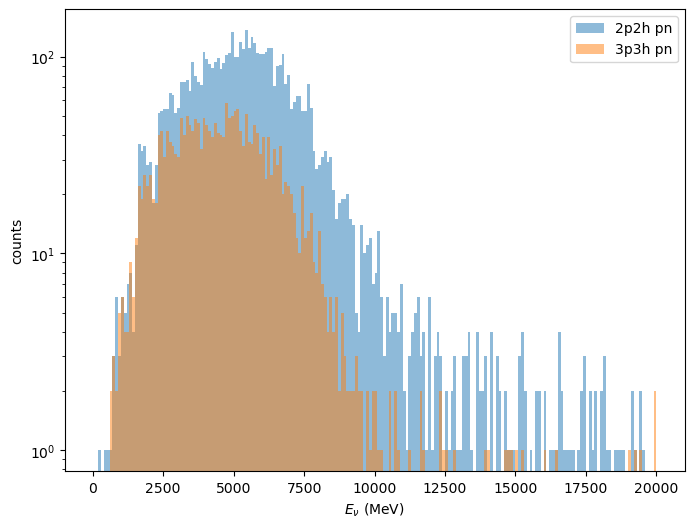

/tmp/ipykernel_3231846/3764424737.py:38: RuntimeWarning: divide by zero encountered in divide
  ratio = (n2p2h + n3p3h) / n2p2h
/tmp/ipykernel_3231846/3764424737.py:38: RuntimeWarning: invalid value encountered in divide
  ratio = (n2p2h + n3p3h) / n2p2h


In [7]:
# Scale up 2p2h strength by 3p3h contribution, pp and pn:
# pp:
category = 'pp'
Enu_max = max(oldInclusive[category]['init_neutrino_E'].max(), oldInclusive3p3h[category ]['init_neutrino_E'].max())
bins = np.arange(0,Enu_max+100, 100)
plt.figure(figsize=(8,6))
n2p2h, _, _ = plt.hist(oldInclusive[category]['init_neutrino_E'], bins=bins, label=f'2p2h {category}', alpha=0.5)
n3p3h, _, _ = plt.hist(oldInclusive3p3h[category ]['init_neutrino_E'], bins=bins, label=f'3p3h {category}', alpha=0.5)
plt.legend()
plt.yscale('log')
plt.xlabel('$E_\\nu$ (MeV)')
plt.ylabel('counts')
plt.show()
ratio = (n2p2h + n3p3h) / n2p2h
ratio = np.nan_to_num(ratio, nan=1.0, posinf=1.0, neginf=1.0)
nthbin = np.searchsorted(bins, oldInclusive[category]['init_neutrino_E'], side="right") - 1

# customize an original weight for old valencia
oldInclusive[category]['weight0'] = np.ones(len(oldInclusive[category])) * np.sum(newExclusive[category]['weight']) / len(oldInclusive[category])
# oldInclusive[category]['weight0'] = np.ones(len(oldInclusive[category]))

oldInclusive[category]['weight0'] = oldInclusive[category]['weight0'] * ratio[nthbin]


# pn:
category='pn'
# Scale up 2p2h strength by 3p3h contribution
Enu_max = max(oldInclusive[category]['init_neutrino_E'].max(), oldInclusive3p3h[category ]['init_neutrino_E'].max())
bins = np.arange(0,Enu_max+100, 100)
plt.figure(figsize=(8,6))
n2p2h, _, _ = plt.hist(oldInclusive[category]['init_neutrino_E'], bins=bins, label=f'2p2h {category}', alpha=0.5)
n3p3h, _, _ = plt.hist(oldInclusive3p3h[category ]['init_neutrino_E'], bins=bins, label=f'3p3h {category}', alpha=0.5)
plt.legend()
plt.yscale('log')
plt.xlabel('$E_\\nu$ (MeV)')
plt.ylabel('counts')
plt.show()
ratio = (n2p2h + n3p3h) / n2p2h
ratio = np.nan_to_num(ratio, nan=1.0, posinf=1.0, neginf=1.0)
nthbin = np.searchsorted(bins, oldInclusive[category]['init_neutrino_E'], side="right") - 1

# customize an original weight for old valencia
# oldInclusive[category]['weight0'] = np.ones(len(oldInclusive[category]))
oldInclusive[category]['weight0'] = np.ones(len(oldInclusive[category])) * np.sum(newExclusive[category]['weight']) / len(oldInclusive[category])
oldInclusive[category]['weight0'] = oldInclusive[category]['weight0'] * ratio[nthbin]

Reweight and plot pp, preFSI:

In [9]:
# prepare dataframes and reweight training

category = 'pp'


# reweight to new inclusive first:
# train reweighter
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    # 'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    # 'init_neutrino_E'
]

reweighter = Reweighter(n_estimators=200, learning_rate=0.1, max_depth=4, min_samples_leaf=20, gb_args={'subsample': 1.0})
reweighter.fit(oldInclusive[category][reweight_variables], newExclusive[category][reweight_variables],
            original_weight=oldInclusive[category]['weight0'],
            target_weight=newExclusive[category]['weight']
)
# reweighter.save_to_pickle(f'/exp/minerva/data/users/zihaolin/BDTReweighters/saved_reweighters_pickle/Valencia/reweighter_Minerva_flux_Valencia_2p2h_newInclusive_to_newExclusive_{category}.pkl')
# # load from saved
# reweighter = Reweighter.load_from_pickle(f'/exp/minerva/data/users/zihaolin/BDTReweighters/saved_reweighters_pickle/Valencia/reweighter_Minerva_flux_Valencia_2p2h_newInclusive_to_newExclusive_{category}.pkl')


,n_estimators,200
,learning_rate,0.1
,max_depth,4
,min_samples_leaf,20
,loss_regularization,5
,gb_args,{'subsample': 1.0}


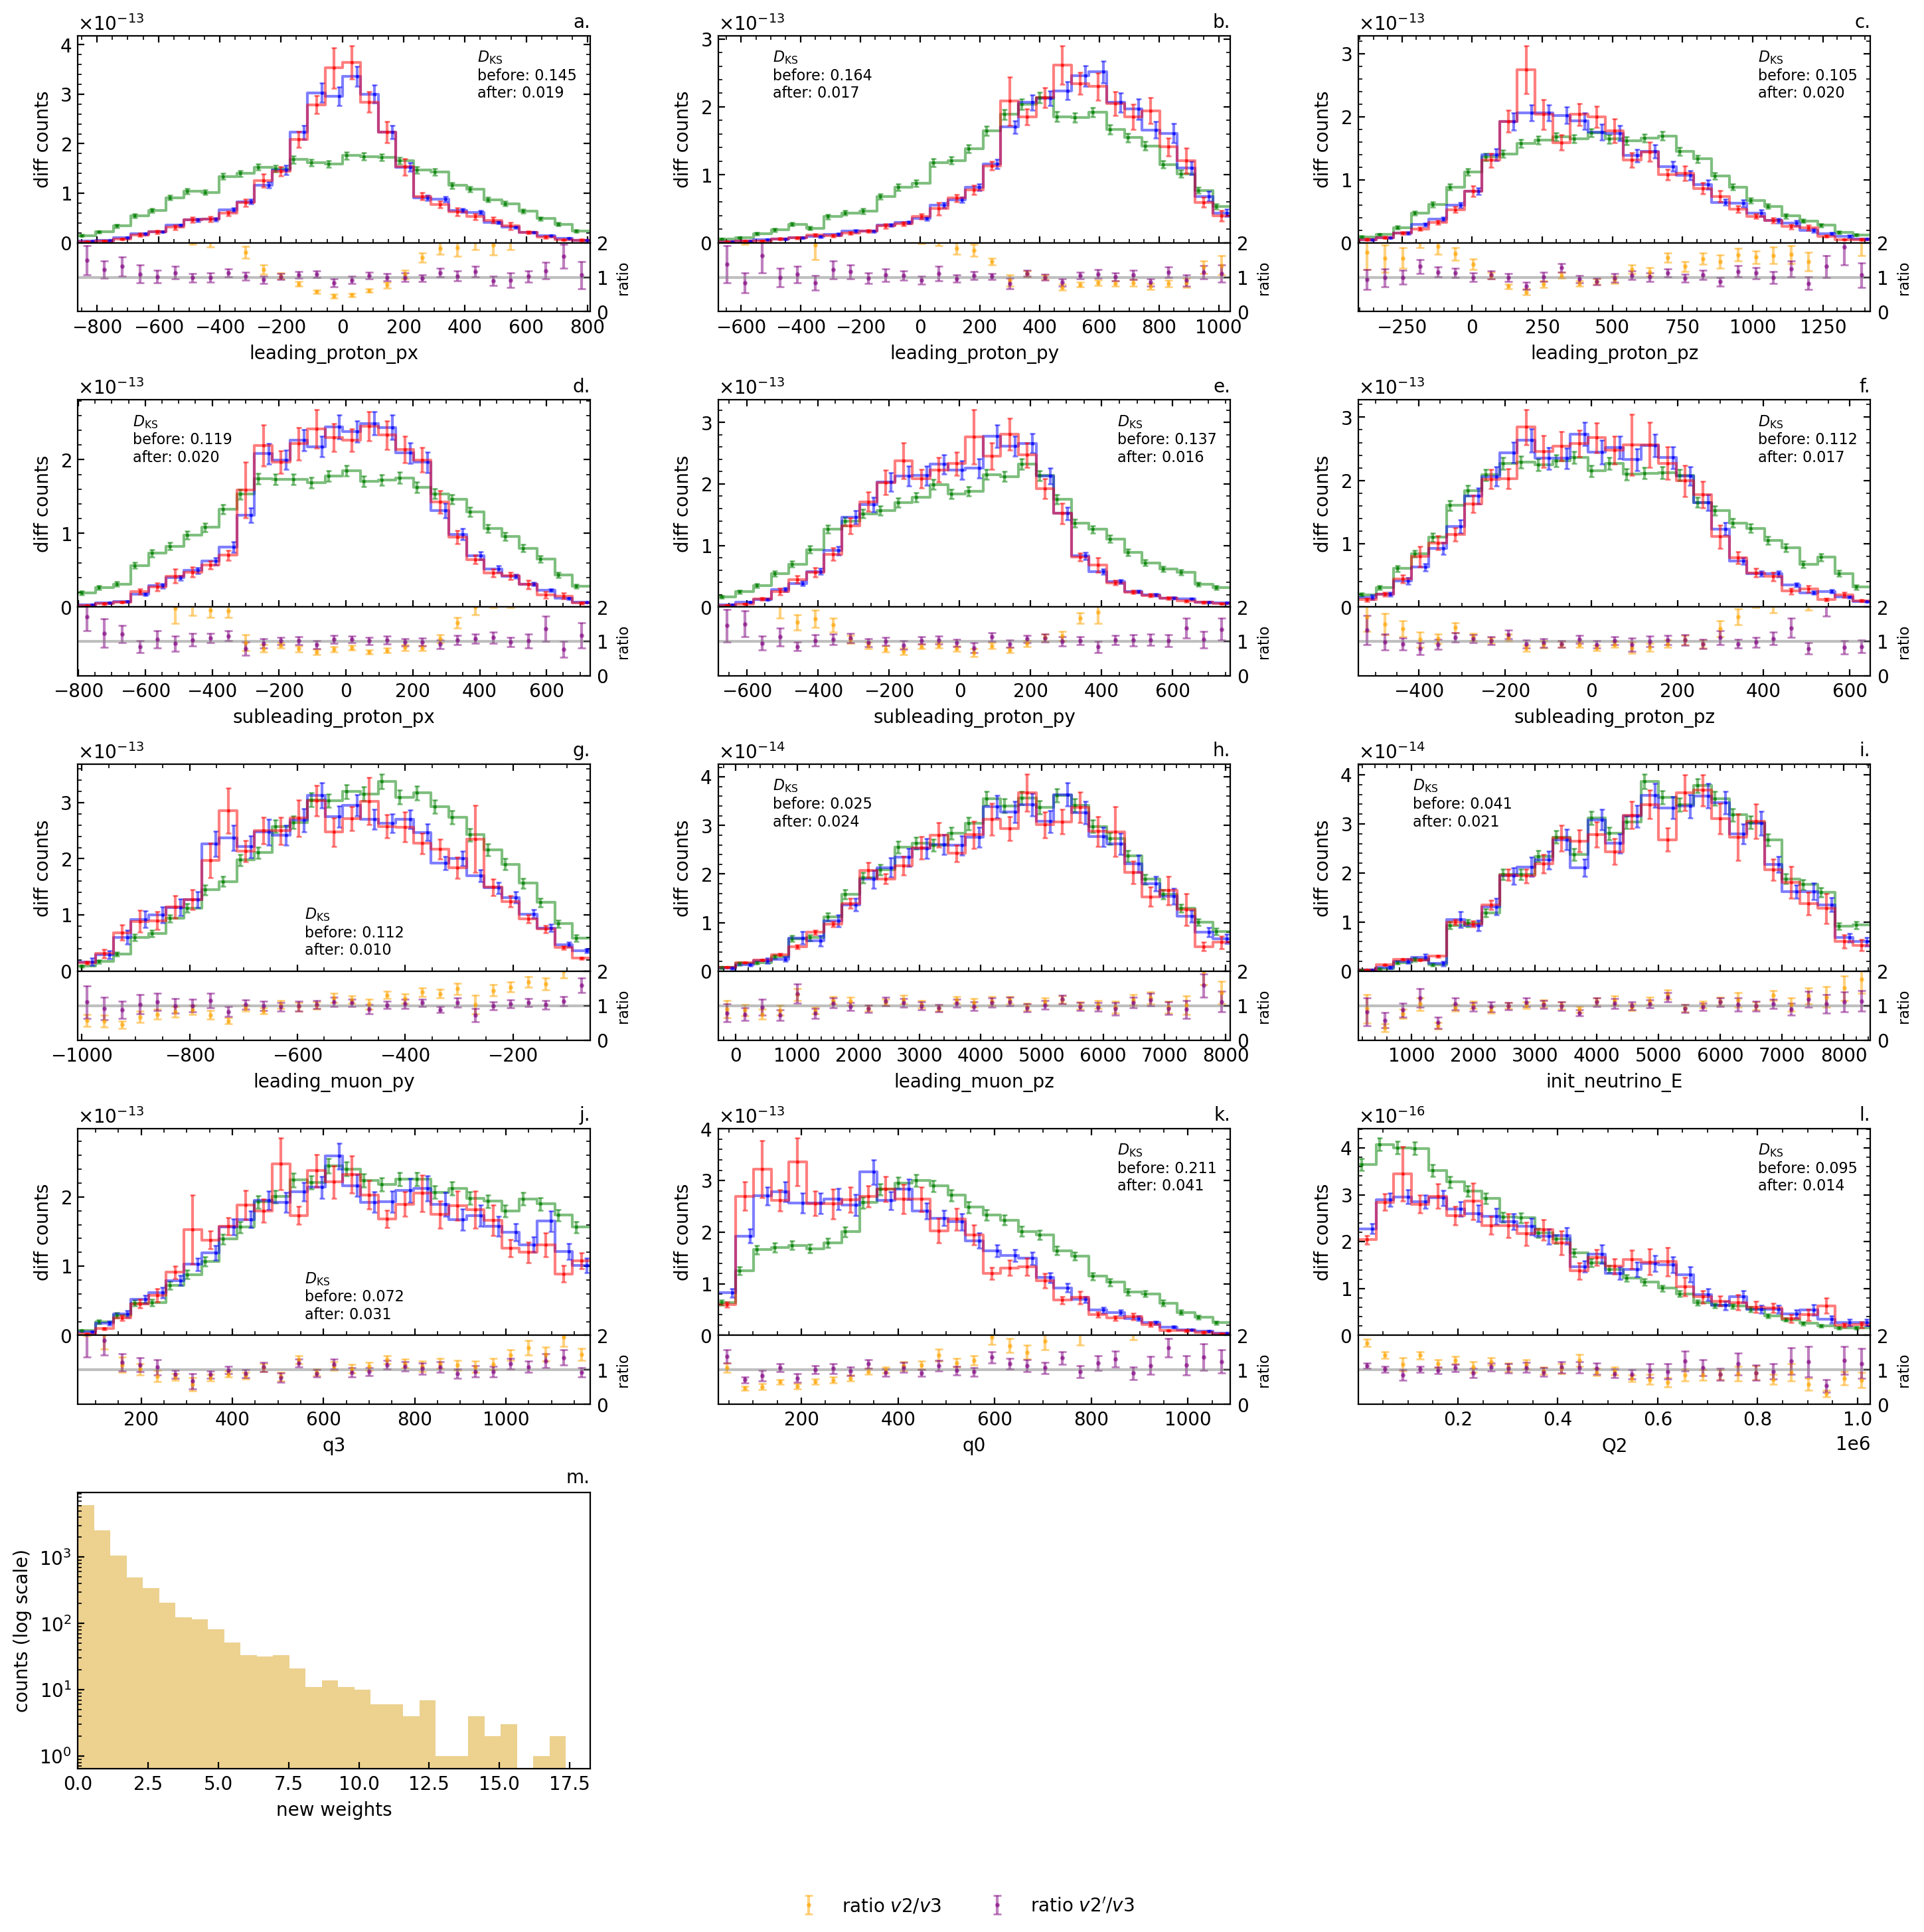

In [10]:
# predict weights and plot. weight3: from old inclusive directly to new exclusive

oldInclusive[category]['weight3'] = reweighter.predict_matched_total_weights(oldInclusive[category][reweight_variables], 
            original_weight=oldInclusive[category]['weight0'],
            target_weight=newExclusive[category]['weight']
)
oldInclusive[category]['weight'] = oldInclusive[category]['weight3']

drawing_variables=[
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    # 'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E',
    'q3', 'q0','Q2',
    'weight',
]

mask = oldInclusive[category]['weight3']>=0
draw_source_target_distributions_and_ratio(oldInclusive[category].loc[mask], newExclusive[category], variables=drawing_variables,
    source_weights=oldInclusive[category].loc[mask]['weight0'], 
    new_source_weights=oldInclusive[category].loc[mask]['weight3'], 
    target_weights=newExclusive[category]['weight']
)


Reweight and plot pn, preFSI

In [11]:
# prepare dataframes and reweight training

category = 'pn'


# reweight to new inclusive first:
# train reweighter
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    # 'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    # 'init_neutrino_E'
]

reweighter = Reweighter(n_estimators=200, learning_rate=0.1, max_depth=4, min_samples_leaf=20, gb_args={'subsample': 1.0})
reweighter.fit(oldInclusive[category][reweight_variables], newExclusive[category][reweight_variables],
            original_weight=oldInclusive[category]['weight0'],
            target_weight=newExclusive[category]['weight']
)
# reweighter.save_to_pickle(f'/exp/minerva/data/users/zihaolin/BDTReweighters/saved_reweighters_pickle/Valencia/reweighter_Minerva_flux_Valencia_2p2h_newInclusive_to_newExclusive_{category}.pkl')
# # load from saved
# reweighter = Reweighter.load_from_pickle(f'/exp/minerva/data/users/zihaolin/BDTReweighters/saved_reweighters_pickle/Valencia/reweighter_Minerva_flux_Valencia_2p2h_newInclusive_to_newExclusive_{category}.pkl')


,n_estimators,200
,learning_rate,0.1
,max_depth,4
,min_samples_leaf,20
,loss_regularization,5
,gb_args,{'subsample': 1.0}


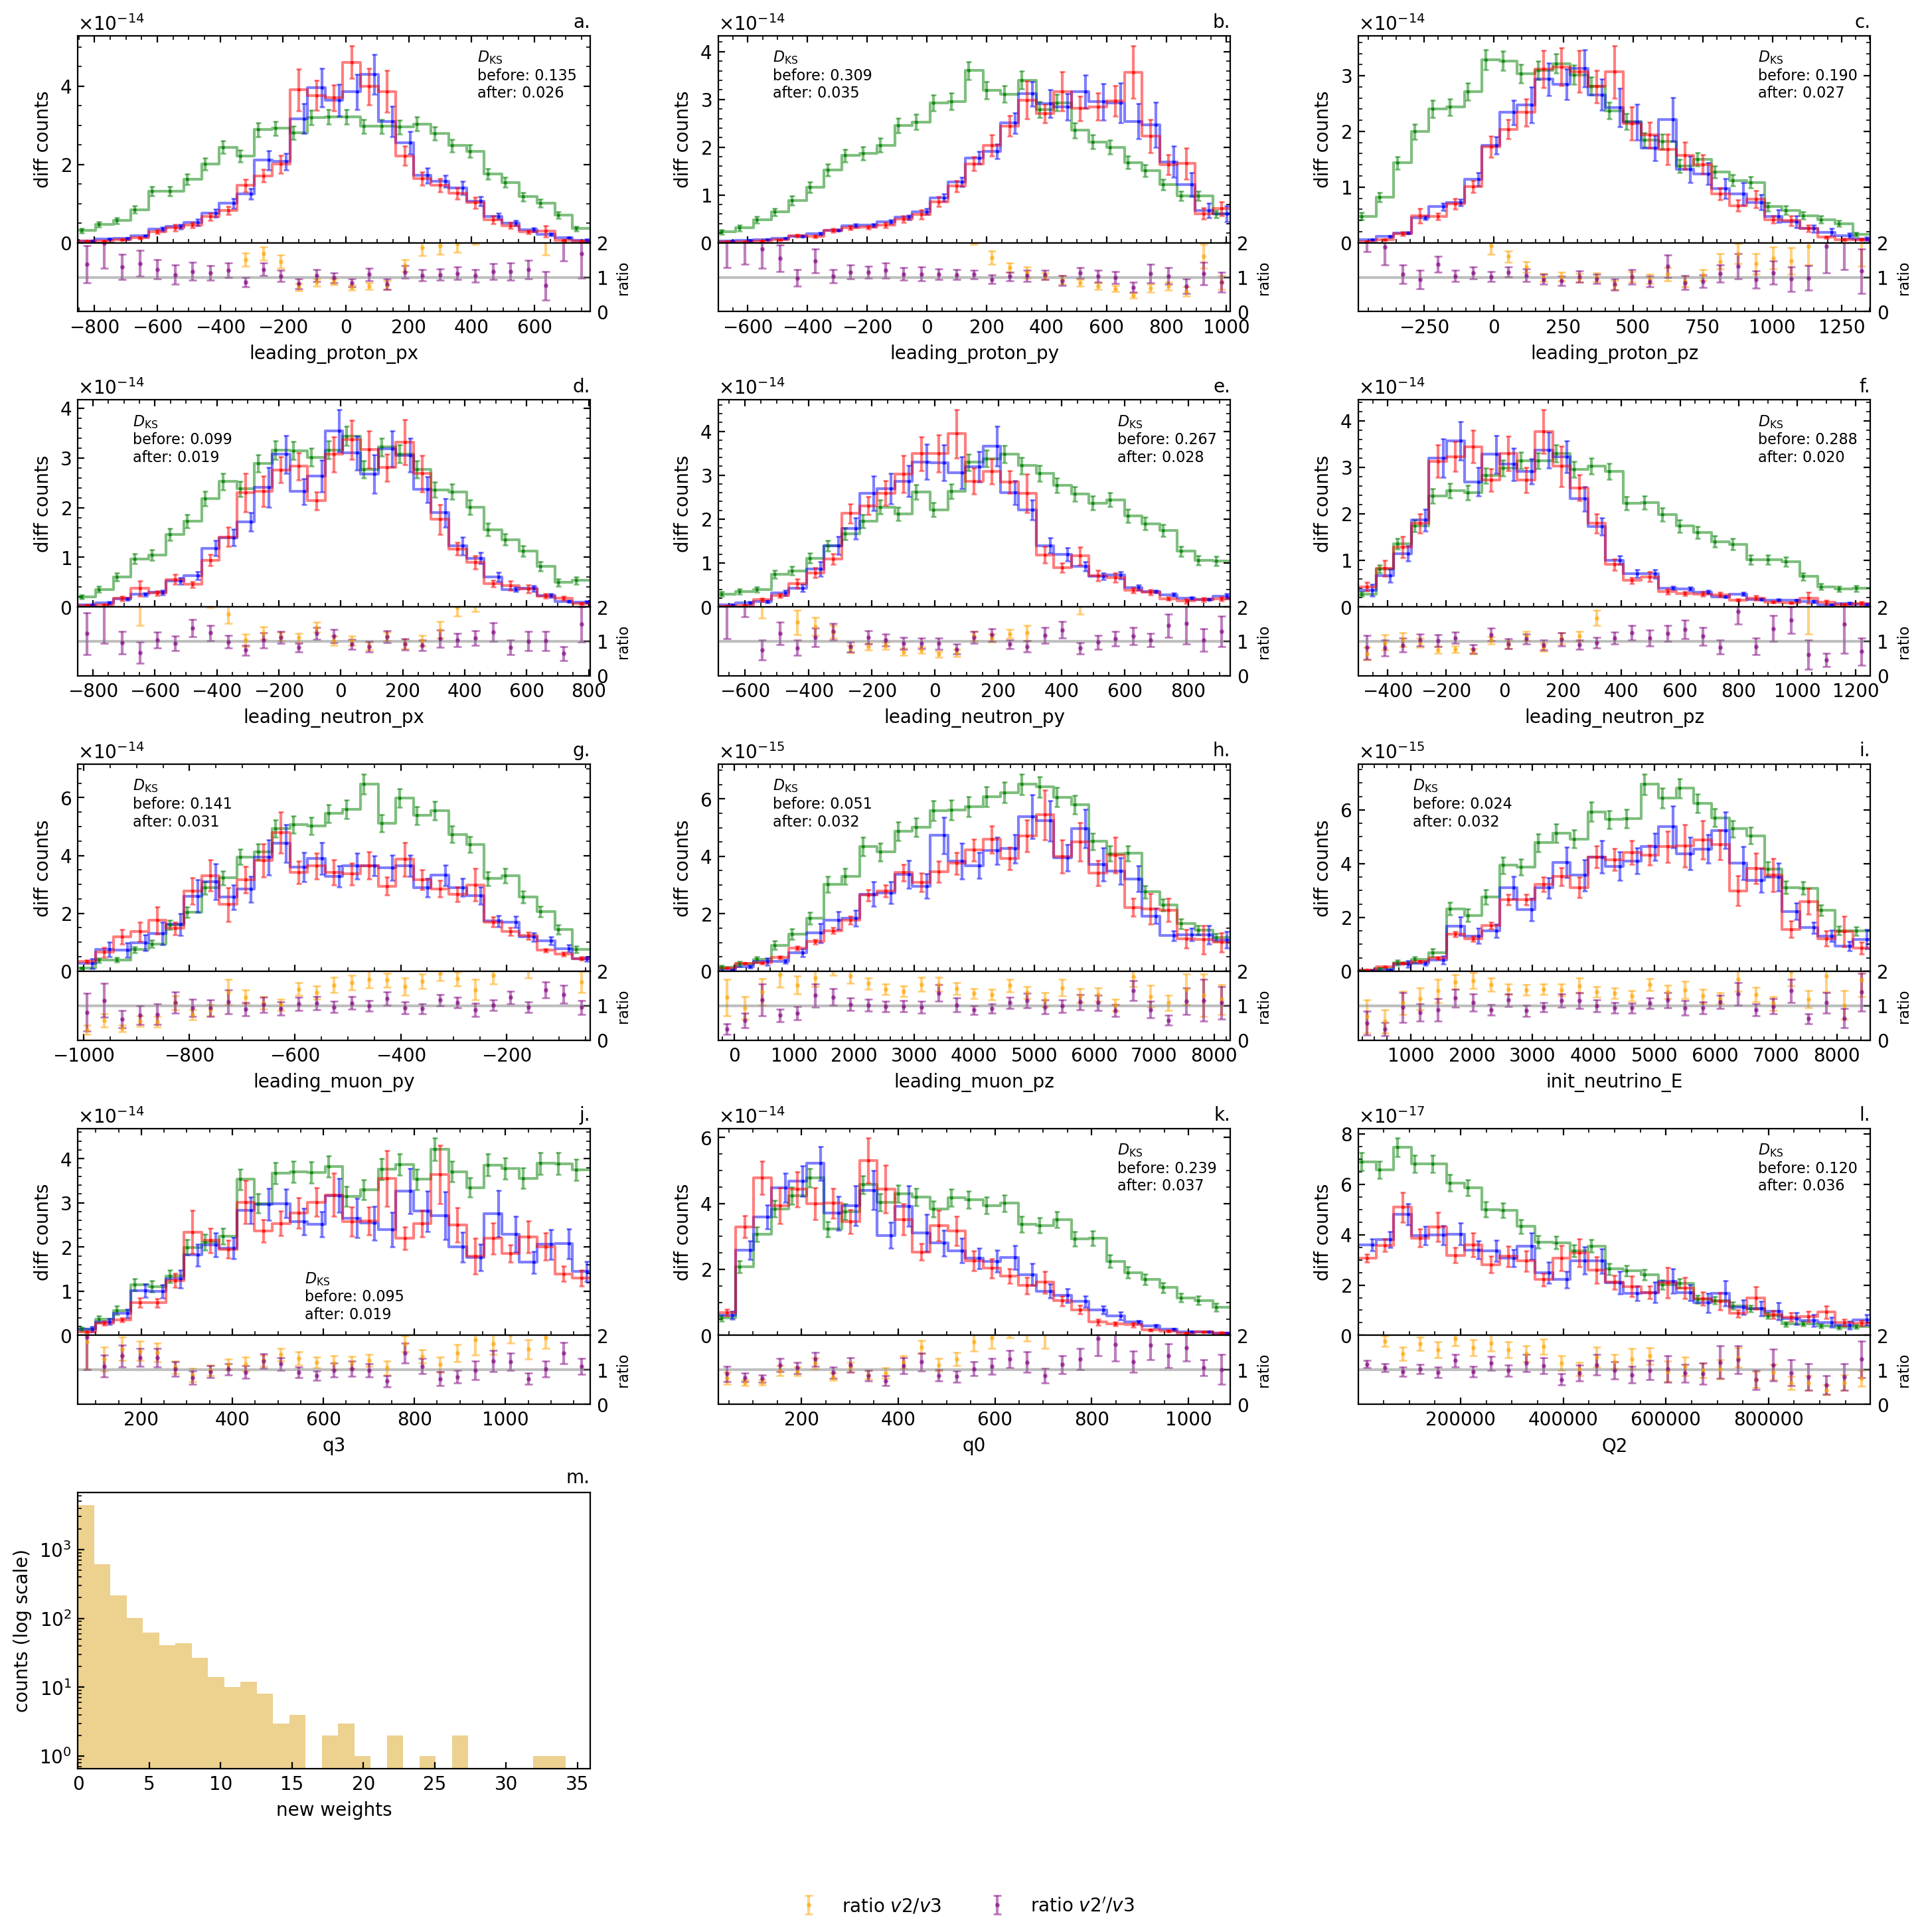

In [12]:
# predict weights and plot. weight3: from old inclusive directly to new exclusive

oldInclusive[category]['weight3'] = reweighter.predict_matched_total_weights(oldInclusive[category][reweight_variables], 
            original_weight=oldInclusive[category]['weight0'],
            target_weight=newExclusive[category]['weight']
)
oldInclusive[category]['weight'] = oldInclusive[category]['weight3']

drawing_variables=[
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    # 'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E',
    'q3', 'q0','Q2',
    'weight',
]

mask = oldInclusive[category]['weight3']>=0
draw_source_target_distributions_and_ratio(oldInclusive[category].loc[mask], newExclusive[category], variables=drawing_variables,
    source_weights=oldInclusive[category].loc[mask]['weight0'], 
    new_source_weights=oldInclusive[category].loc[mask]['weight3'], 
    target_weights=newExclusive[category]['weight']
)


Save weights to csv:

In [15]:
oldInclusive['pp'][['entry','weight0','weight3']].to_csv(
    '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors_weights_pp.csv', index=False)
oldInclusive['pn'][['entry','weight0','weight3']].to_csv(
    '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors_weights_pn.csv', index=False)

In [16]:
# scaling up or down
# scale_2p2h = 1e-42
scale_2p2h = 5.6e-44
# scale_2p2h = 1
# scale_2p2h = 1
for category in ['pp', 'pn']:
    df = pd.read_csv(f'/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors_weights_{category}.csv')
    # df['weight3'] = df['weight0']*df['weight3']
    df['weight0'] = scale_2p2h * df['weight0']
    df['weight3'] = scale_2p2h * df['weight3'] * len(df)/df['weight3'].sum()
    df.to_csv(f'/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors_weights_{category}.csv', index=False)
